# Range evaluation

**Part A — Preflop latent hand posteriors** over 169 classes (prior-only vs population vs player-tilted E-step). NLL / ranks / ECDF use only hands where the **target** is still in through `PART_A_TARGET_IN_HAND_THROUGH` (see setup cell).

**Part B — `filter_sessions_range_history_<em|newton>.csv`** combo-range export (enrichment + calibration columns). Filename suffix is controlled by `THETA_OPTIMIZER` in the setup cell (`"em"` or `"newton"`).

Splits: `sessions_theta` / `sessions_filter`. Code: `utils.eval.range_evaluation_helpers`.

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

def _find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for x in (p, *p.parents):
        if (x / "runners" / "common.py").is_file():
            return x
    raise FileNotFoundError("Run from inside the repo (runners/common.py not found).")

REPO = _find_repo_root()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

# Artifacts tag: must match exports from find_theta / filter_sessions ("em" or "newton").
THETA_OPTIMIZER = "em"

# Part A (cells 4–7): only bundle hands where the target is still in through this street end
# (each earlier street in the chain must exist on the hand). None = no filter (legacy).
PART_A_TARGET_IN_HAND_THROUGH = "pre-flop"  # "pre-flop" | "flop" | "turn" | "river" | None

import json

import matplotlib.pyplot as plt
import numpy as np

from utils.eval.range_evaluation_helpers import (
    em_and_online_hand_refs,
    compute_all_posterior_results,
    true_hand_nll,
    ranks_from_results,
    default_observer_map,
)
from utils.eval.player_thetas_evaluation_helpers import load_global_betas, load_player_thetas

priors = json.loads((REPO / "artifacts" / "global_priors.json").read_text())
BETA_PRE, _, _ = load_global_betas(priors)
thetas_payload = json.loads(
    (REPO / "artifacts" / f"player_thetas_{THETA_OPTIMIZER}.json").read_text()
)
PLAYERS, _, THETA_PRE = load_player_thetas(thetas_payload)
OBSERVER_OF = default_observer_map(PLAYERS)
print("observer map:", OBSERVER_OF)
print("THETA_OPTIMIZER:", THETA_OPTIMIZER)
print("PART_A_TARGET_IN_HAND_THROUGH:", PART_A_TARGET_IN_HAND_THROUGH)

observer map: {'MrBlue': 'Bill', 'Bill': 'Pluribus', 'Pluribus': 'MrBlue'}
THETA_OPTIMIZER: newton
PART_A_TARGET_IN_HAND_THROUGH: pre-flop


In [6]:
em_refs, online_refs = em_and_online_hand_refs(REPO)
print("em hands", len(em_refs), "online hands", len(online_refs))

em hands 541 online hands 1015


In [7]:
RESULTS = compute_all_posterior_results(
    PLAYERS,
    OBSERVER_OF,
    beta_pre=BETA_PRE,
    theta_pre=THETA_PRE,
    em_refs=em_refs,
    online_refs=online_refs,
    require_target_in_hand_through=PART_A_TARGET_IN_HAND_THROUGH,
)
_sample = (PLAYERS[0], "em", "player")
print(
    "settings",
    len(RESULTS),
    "| Part A bundled hands (sample)",
    _sample,
    "n =",
    len(RESULTS[_sample]),
    "| filter =",
    PART_A_TARGET_IN_HAND_THROUGH,
)

settings 18 | Part A bundled hands (sample) ('MrBlue', 'em', 'player') n = 153 | filter = pre-flop


In [8]:
print(f"{'player':<10} {'split':<7} {'predictor':<11} {'NLL':>8}")
for player in PLAYERS:
    for split in ("em", "online"):
        for predictor in ("prior_only", "population", "player"):
            v = true_hand_nll(RESULTS[(player, split, predictor)])
            print(f"{player:<10} {split:<7} {predictor:<11} {v:>8.4f}")

player     split   predictor        NLL
MrBlue     em      prior_only    5.3688
MrBlue     em      population    5.0864
MrBlue     em      player        5.0612
MrBlue     online  prior_only    5.2527
MrBlue     online  population    5.0324
MrBlue     online  player        5.0135
Bill       em      prior_only    5.3009
Bill       em      population    4.9547
Bill       em      player        4.9697
Bill       online  prior_only    5.2570
Bill       online  population    4.9380
Bill       online  player        4.9511
Pluribus   em      prior_only    5.2961
Pluribus   em      population    5.0041
Pluribus   em      player        5.0021
Pluribus   online  prior_only    5.2994
Pluribus   online  population    5.0077
Pluribus   online  player        5.0056


In [9]:
from utils.strength.preflop import all_169_classes
ALL_169 = all_169_classes()
IX = {h: i for i, h in enumerate(ALL_169)}
RANKS = {k: ranks_from_results(res, all_169=ALL_169, index_of=IX) for k, res in RESULTS.items()}
print(f"{'player':<10} {'split':<7} {'predictor':<11} {'mean_rank':>10} {'median_rank':>12}")
for key, r in RANKS.items():
    if r.size == 0:
        continue
    p, sp, pred = key
    print(f"{p:<10} {sp:<7} {pred:<11} {r.mean():>10.2f} {np.median(r):>12.1f}")

player     split   predictor    mean_rank  median_rank
MrBlue     em      prior_only       86.84         90.0
MrBlue     em      population       72.81         80.0
MrBlue     em      player           70.76         77.0
MrBlue     online  prior_only       76.47         85.0
MrBlue     online  population       66.50         69.0
MrBlue     online  player           65.36         68.0
Bill       em      prior_only       81.45         84.5
Bill       em      population       59.95         62.5
Bill       em      player           60.92         62.5
Bill       online  prior_only       73.95         84.0
Bill       online  population       60.66         59.0
Bill       online  player           61.36         60.0
Pluribus   em      prior_only       77.58         86.5
Pluribus   em      population       66.20         70.0
Pluribus   em      player           66.11         70.0
Pluribus   online  prior_only       79.72         87.0
Pluribus   online  population       65.69         71.5
Pluribus  

In [10]:
KS = (1, 5, 10, 20, 50)
header = ["player", "split", "predictor"] + [f"top-{k}" for k in KS]
print("  ".join(f"{h:<10}" for h in header))
for (p, sp, pred), r in RANKS.items():
    if r.size == 0:
        continue
    cells = [p, sp, pred] + [f"{(r <= k).mean():.3f}" for k in KS]
    print("  ".join(f"{c:<10}" for c in cells))

player      split       predictor   top-1       top-5       top-10      top-20      top-50    
MrBlue      em          prior_only  0.026       0.065       0.111       0.163       0.222     
MrBlue      em          population  0.033       0.098       0.144       0.203       0.392     
MrBlue      em          player      0.033       0.092       0.150       0.229       0.425     
MrBlue      online      prior_only  0.032       0.091       0.136       0.197       0.320     
MrBlue      online      population  0.036       0.087       0.159       0.272       0.401     
MrBlue      online      player      0.039       0.094       0.162       0.269       0.424     
Bill        em          prior_only  0.034       0.123       0.158       0.212       0.274     
Bill        em          population  0.027       0.151       0.247       0.363       0.459     
Bill        em          player      0.027       0.151       0.247       0.329       0.445     
Bill        online      prior_only  0.050       0.

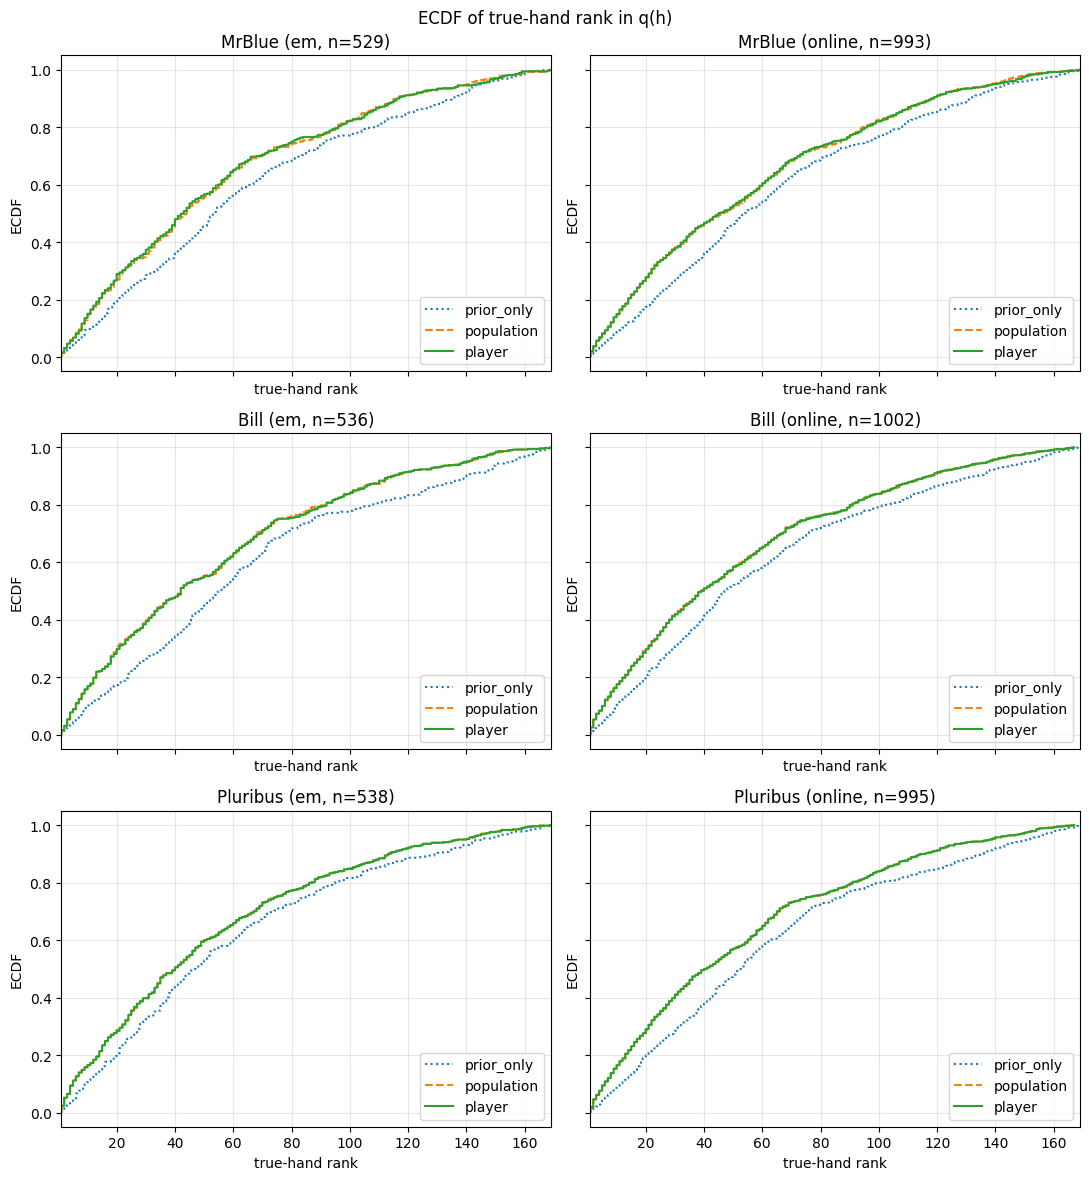

In [7]:
def ecdf(arr):
    x = np.sort(arr)
    y = np.arange(1, x.size + 1) / x.size
    return x, y

fig, axes = plt.subplots(len(PLAYERS), 2, figsize=(11, 4 * len(PLAYERS)), sharex=True, sharey=True)
if len(PLAYERS) == 1:
    axes = np.array([axes])
for i, player in enumerate(PLAYERS):
    for j, split in enumerate(("em", "online")):
        ax = axes[i, j]
        for predictor, ls in (("prior_only", ":"), ("population", "--"), ("player", "-")):
            r = RANKS[(player, split, predictor)]
            if r.size == 0:
                continue
            x, y = ecdf(r)
            ax.step(x, y, where="post", label=predictor, linestyle=ls)
        ax.set_title(f"{player} ({split}, n={RANKS[(player, split, 'player')].size})")
        ax.set_xlabel("true-hand rank")
        ax.set_ylabel("ECDF")
        ax.set_xlim(1, 169)
        ax.legend(loc="lower right")
        ax.grid(alpha=0.3)
fig.suptitle("ECDF of true-hand rank in q(h)")
fig.tight_layout()
plt.show()

## Part B — filter-session combo-range CSV

Requires `artifacts/filter_sessions_range_history_{THETA_OPTIMIZER}.csv` (same `THETA_OPTIMIZER` as in the setup cell: `"em"` or `"newton"`). Set `MAX_ROWS = None` for a full run.

In [13]:
from IPython.display import display
from pprint import pprint

from utils.eval.range_evaluation_helpers import (
    evaluate_observer_fold_vs_target_realized_strength,
    run_filter_sessions_range_evaluation,
)

CSV_PATH = REPO / "artifacts" / f"filter_sessions_range_history_{THETA_OPTIMIZER}.csv"
STRENGTH_MC_SAMPLES = 100
RNG_SEED = 0
MAX_ROWS = 1000

if not CSV_PATH.is_file():
    print(f"Skip Part B: missing {CSV_PATH}")
else:
    out = run_filter_sessions_range_evaluation(
        REPO,
        csv_path=CSV_PATH,
        theta_optimizer=THETA_OPTIMIZER,
        strength_mc_samples=STRENGTH_MC_SAMPLES,
        rng_seed=RNG_SEED,
        max_rows=MAX_ROWS,
        verbose=True,
    )
    print("rows:", out["n_rows"], "combo prob cols:", out["n_combo_prob_cols"])
    print("range_csv_theta_tag:", out.get("range_csv_theta_tag"))
    print("combo_prob_fingerprint_raw:", out.get("combo_prob_fingerprint_raw"))
    _tag = out.get("range_csv_theta_tag")
    if _tag and str(THETA_OPTIMIZER) != str(_tag):
        print(
            "WARNING: THETA_OPTIMIZER does not match CSV filename tag "
            f"(THETA_OPTIMIZER={THETA_OPTIMIZER!r}, tag={_tag!r})"
        )
    print("streets:", out["streets"])
    print("excluded (target not in for that street):", out["n_rows_excluded_not_in_hand"])
    print("--- calibration aggregates (all remaining rows) ---")
    pprint(out["calibration_row_aggregates"])
    print("--- calibration aggregates (mean per hand, then mean over hands) ---")
    pprint(out["calibration_hand_aggregates"])
    display(out["df_calib"].head())

[eval] enrich_online_range_dataframe: 1000 rows | pluribus_root=/Users/kevinliu/Desktop/bayesian poker/pluribus
[eval] enrich … row 1/1000
[eval] enrich … row 100/1000
[eval] enrich … row 200/1000
[eval] enrich … row 300/1000
[eval] enrich … row 400/1000
[eval] enrich … row 500/1000
[eval] enrich … row 600/1000
[eval] enrich … row 700/1000
[eval] enrich … row 800/1000
[eval] enrich … row 900/1000
[eval] enrich … row 1000/1000
[eval] enrich_online_range_dataframe: done (70 unique session/hand hands cached)
[eval] add_calibration_columns: 346 rows | strength_mc_samples=100
[eval] calibration … row 1/346
[eval] calibration … row 50/346
[eval] calibration … row 100/346
[eval] calibration … row 150/346
[eval] calibration … row 200/346
[eval] calibration … row 250/346
[eval] calibration … row 300/346
[eval] calibration … row 346/346
[eval] add_calibration_columns: done
rows: 346 combo prob cols: 1326
range_csv_theta_tag: newton
combo_prob_fingerprint_raw: 2f897f9f558bb0b8330351eb7eee36656cba

,session,hand_number,street,observer,target,3s2s,4s2s,5s2s,6s2s,7s2s,...,made_strength_pct__AsKc,made_strength_pct__AhKc,made_strength_pct__AdKc,made_strength_pct__AcKc,made_strength_pct__AhAs,made_strength_pct__AdAs,made_strength_pct__AcAs,made_strength_pct__AdAh,made_strength_pct__AcAh,made_strength_pct__AcAd
4,40b,121,pre-flop,Bill,MrBlue,0.000913,0.000896,0.000877,0.000856,0.000839,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,40b,121,flop,Bill,MrBlue,0.000912,0.000898,0.001186,0.000867,0.000861,...,NaN,NaN,NaN,NaN,0.912581,0.912581,0.912581,0.912581,0.912581,0.912581
6,40b,121,turn,Bill,MrBlue,0.000935,0.000929,0.001235,0.000911,0.000921,...,NaN,NaN,NaN,NaN,0.956039,0.956039,0.956039,0.956039,0.956039,0.956039
7,40b,121,river,Bill,MrBlue,0.000000,0.000882,0.001232,0.000872,0.000929,...,NaN,NaN,NaN,NaN,0.955051,0.955051,0.955051,0.955051,0.955051,0.955051
12,40b,121,pre-flop,Pluribus,MrBlue,0.000911,0.000894,0.000875,0.000854,0.000837,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observer fold vs. target realized strength

Postflop rows where **both** players were in at the **start** of the street and the **observer** folded that street: compare realized **made percentile** and **draw** (same definitions as `actual_made_pct` / `actual_draw` in calibration). **Consistent** = observer weaker than target on that axis (fold looks sensible in this crude sense); **inconsistent** = observer stronger. See `evaluate_observer_fold_vs_target_realized_strength` in `utils.eval.range_evaluation_helpers`.

In [20]:
# Requires Part B cell above (defines `out`, `CSV_PATH`) when the CSV exists.
from IPython.display import display
from pprint import pprint

SHOW_FOLD_DETAIL = False  # set True for a per-row DataFrame (can be large)

if not CSV_PATH.is_file():
    print("Skip fold eval: missing CSV (same as Part B).")
elif "out" not in globals():
    print("Run the Part B cell above first so `out` is defined.")
else:
    FOLD_VS_TARGET = evaluate_observer_fold_vs_target_realized_strength(
        out["df_calib"],
        REPO / "pluribus",
        require_target_alive_at_street_end=True,
        return_detail=SHOW_FOLD_DETAIL,
        verbose=False,
    )
    pprint(FOLD_VS_TARGET["summary"])
    if SHOW_FOLD_DETAIL and FOLD_VS_TARGET.get("detail") is not None:
        display(FOLD_VS_TARGET["detail"].head(20))


{'draw_consistent': 4,
 'draw_consistent_rate_excl_ties': 0.5714285714285714,
 'draw_inconsistent': 3,
 'draw_tie': 9,
 'made_consistent': 10,
 'made_consistent_rate_excl_ties': 0.625,
 'made_inconsistent': 6,
 'made_tie': 0,
 'n_csv_rows_postflop_street': 209,
 'n_draw_defined': 16,
 'n_eligible_observer_folds': 16}


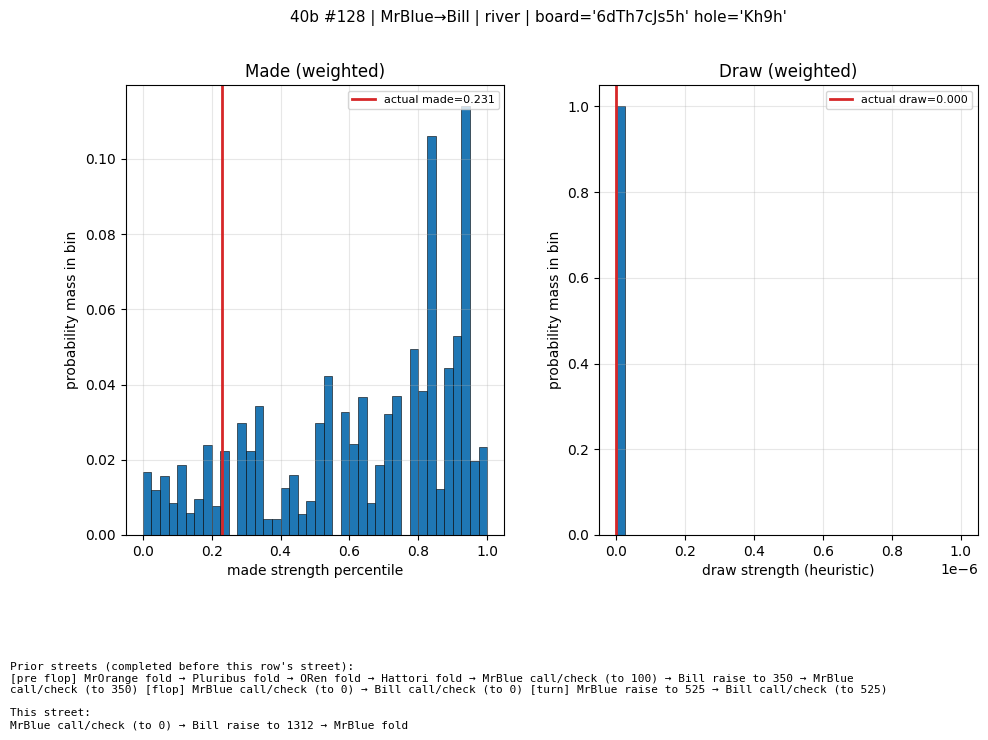

In [21]:
from utils.eval import combo_probability_columns, plot_made_distribution

_df_calib = out["df_calib"]

_combo_cols = combo_probability_columns(_df_calib)
fig, _axes = plot_made_distribution(
    _df_calib,
    session='40b',
    hand_number='128',
    observer='MrBlue',
    target='Bill',
    street='river',
    combo_cols=_combo_cols,
    pluribus_root=REPO / "pluribus",
)
plt.show()

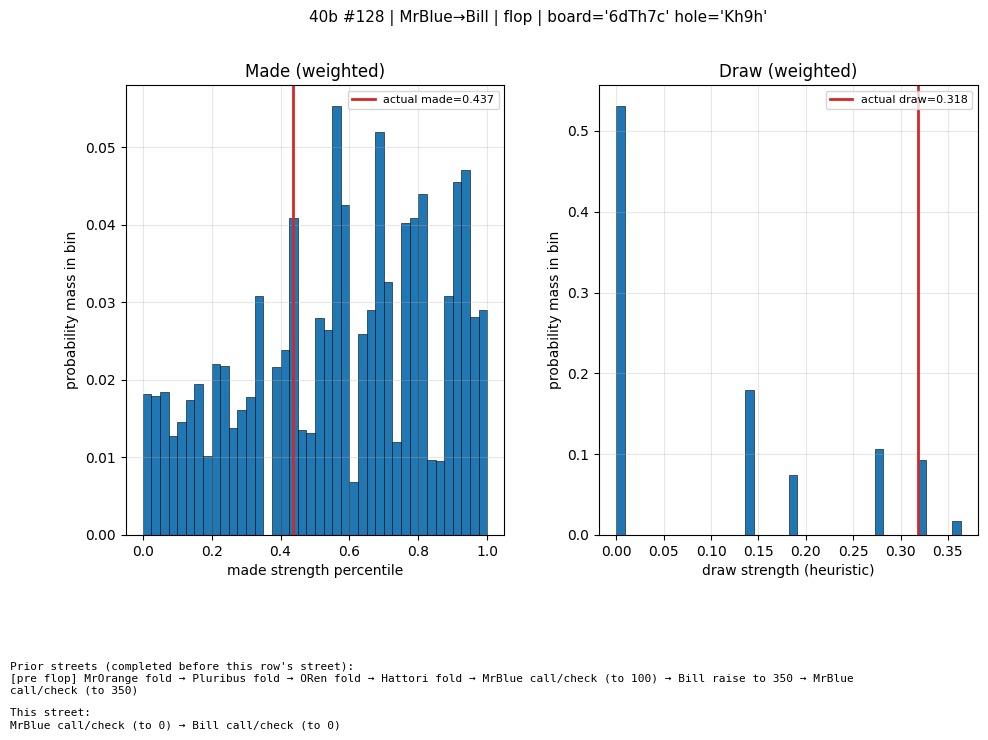

In [17]:
_combo_cols = combo_probability_columns(_df_calib)
fig, _axes = plot_made_distribution(
    _df_calib,
    session='40b',
    hand_number='128',
    observer='MrBlue',
    target='Bill',
    street='flop',
    combo_cols=_combo_cols,
    pluribus_root=REPO / "pluribus",
)
plt.show()

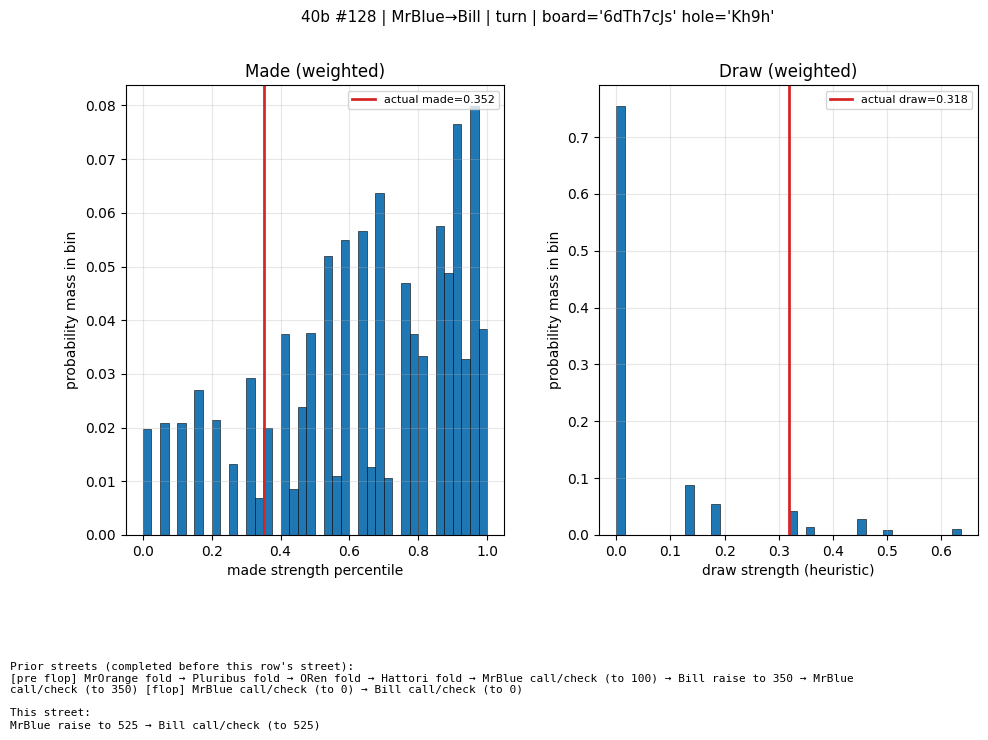

In [19]:
_combo_cols = combo_probability_columns(_df_calib)
fig, _axes = plot_made_distribution(
    _df_calib,
    session='40b',
    hand_number='128',
    observer='MrBlue',
    target='Bill',
    street='turn',
    combo_cols=_combo_cols,
    pluribus_root=REPO / "pluribus",
)
plt.show()

In [38]:
_df_calib[
    (_df_calib["session"] == '40b')
    & (_df_calib["hand_number"] == 128)
    & (_df_calib["street"] == 'river')
]


,session,hand_number,street,observer,target,3s2s,4s2s,5s2s,6s2s,7s2s,...,made_strength_pct__AsKc,made_strength_pct__AhKc,made_strength_pct__AdKc,made_strength_pct__AcKc,made_strength_pct__AhAs,made_strength_pct__AdAs,made_strength_pct__AcAs,made_strength_pct__AdAh,made_strength_pct__AcAh,made_strength_pct__AcAd
141,40b,128,river,MrBlue,Bill,0.000559,0.000546,0.000311,0.000777,0.000872,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949
145,40b,128,river,Bill,MrBlue,0.001547,0.001428,0.001698,0.001193,0.001109,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949
149,40b,128,river,MrBlue,Pluribus,0.000825,0.000832,0.001120,0.001132,0.001140,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949
153,40b,128,river,Pluribus,MrBlue,0.001548,0.001428,0.001698,0.001193,0.001109,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949
157,40b,128,river,Bill,Pluribus,0.000825,0.000832,0.001120,0.001132,0.001140,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949
161,40b,128,river,Pluribus,Bill,0.000559,0.000546,0.000311,0.000776,0.000872,...,0.343939,0.343939,0.343939,0.343939,0.844949,0.844949,0.844949,0.844949,0.844949,0.844949


In [30]:
combo_cols = [col for col in _df_calib.iloc[0].index if len(col) == 4]

In [40]:
def top_k_hands(session, hand_number, street, observer, target, k=10):
    row = _df_calib[
        (_df_calib["session"] == session)
        & (_df_calib["hand_number"] == hand_number)
        & (_df_calib["street"] == street)
        & (_df_calib["observer"] == observer)
        & (_df_calib["target"] == target)
    ].iloc[0]

    sorted_cols = sorted(combo_cols, key=lambda col: row[col], reverse=True)
    return {col: row[col].item() for col in sorted_cols[:k]}


top_k_hands(session='40b', hand_number=128, street='river', observer='MrBlue', target='Bill', k=10)

{'Jh7h': 0.0035597176697895,
 'TcTs': 0.0035383593643522,
 'TcTd': 0.0035383192863614,
 'TdTs': 0.0035380537377513,
 'Jh6h': 0.0035316369818184,
 'Jd7d': 0.0034794803952731,
 'Jc6c': 0.0034530666170222,
 'JdTd': 0.0033854800343064,
 'JcTc': 0.0033843062338212,
 'JcJd': 0.0032085155052387}